# Data preparation v2 — pulse features and the Kaggle test set

This notebook extends the original preparation (v1) in two ways:

1. **Five new pulse features per chunk**, added to the original seven. The strongest published results on this dataset relied on pulse-level information, while v1 only described *how big* the spikes in each chunk were, not *how many* there were.
2. **The Kaggle test set (`test.parquet`, 20,337 signals) is processed as well**, so the final model can be submitted to Kaggle and scored on the same hidden test set as the published results.

The original seven features and the train/validation/test split are reproduced exactly as in v1, so results stay comparable and the effect of the new features can be measured on its own.

**Before running:** attach the competition data (**Add Input > Competition Datasets**, `vsb-power-line-fault-detection`). No GPU is needed. Run with `LIMIT = 60` first as a quick test, then set `LIMIT = None` and commit with **Save & Run All**. The full run processes 29,049 signals and takes roughly 1–2 hours in the background.

## 1. Imports and settings

New settings for the pulse features:
- `PEAK_LOW = 5`: a pulse is counted if it is at least 5 times the signal's noise level. For 800,000 samples of pure noise, the largest values reach only about 5.2 times the noise level, so this threshold mostly ignores noise.
- `PEAK_HIGH = 8`: a second, stricter level for strong pulses.
- `MIN_PEAK_DISTANCE = 20`: pulses closer than 20 samples (0.5 µs) count as one, so the ringing after a single discharge is not counted several times.

In [1]:
import json
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pywt
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

DATA_DIR = '/kaggle/input/competitions/vsb-power-line-fault-detection'
OUT_DIR = '/kaggle/working'

N_SAMPLES = 800_000
DURATION = 0.02
FS = N_SAMPLES / DURATION          # 40 MHz
HIGHPASS_CUTOFF = 10_000           # Hz, unchanged from v1
N_CHUNKS = 160
CHUNK_LEN = N_SAMPLES // N_CHUNKS  # 5,000 samples per chunk
SEED = 42

PEAK_LOW = 5                       # pulse threshold, in multiples of the noise level
PEAK_HIGH = 8                      # stricter threshold for strong pulses
MIN_PEAK_DISTANCE = 20             # samples (0.5 microseconds)

FEATURE_NAMES = ['mean', 'std', 'min', 'max', 'range', 'p1', 'p99',            # v1 features
                 'pulses_5sd', 'pulses_8sd', 'pos_pulses_5sd', 'neg_pulses_5sd', 'pulse_strength_sum']
N_FEATURES = len(FEATURE_NAMES)    # 12

LIMIT = 60                         # test on 60 signals per set first; set to None for all signals

## 2. Load the labels and reproduce the v1 split

The split code and seed are identical to v1, so every signal lands in the same set as before (training 6,096, validation 1,308, test 1,308).

In [2]:
meta = pd.read_csv(f'{DATA_DIR}/metadata_train.csv')
meta_kaggle = pd.read_csv(f'{DATA_DIR}/metadata_test.csv')

meas = meta.groupby('id_measurement')['target'].max().reset_index()
train_ids, temp_ids = train_test_split(meas['id_measurement'], test_size=0.30,
                                       stratify=meas['target'], random_state=SEED)
temp = meas[meas['id_measurement'].isin(temp_ids)]
val_ids, test_ids = train_test_split(temp['id_measurement'], test_size=0.50,
                                     stratify=temp['target'], random_state=SEED)
split_map = {**{m: 'train' for m in train_ids}, **{m: 'val' for m in val_ids}, **{m: 'test' for m in test_ids}}
meta['split'] = meta['id_measurement'].map(split_map)
assert meta['split'].notna().all()

print(meta.groupby('split')['target'].agg(count='count', pd_share='mean'))
print('Kaggle test signals:', len(meta_kaggle), '| measurements:', meta_kaggle['id_measurement'].nunique())

       count  pd_share
split                 
test    1308  0.055810
train   6096  0.061188
val     1308  0.060398
Kaggle test signals: 20337 | measurements: 6779


## 3. Preprocessing and feature functions

`highpass`, `wavelet_denoise` and the seven v1 features are unchanged.

**New: `pulse_features`.** After filtering and denoising:
1. The signal's noise level σ is estimated with the median absolute deviation, which is not distorted by the pulses themselves.
2. The signal is divided by σ, so all thresholds are relative to that signal's own noise. This keeps the features fair between quiet and noisy signals.
3. `scipy.signal.find_peaks` finds pulses (peaks in the absolute signal) at least 5σ high and at least 20 samples apart.
4. For each of the 160 chunks, five numbers are recorded:
   - `pulses_5sd`: number of pulses of at least 5σ
   - `pulses_8sd`: number of strong pulses of at least 8σ
   - `pos_pulses_5sd` and `neg_pulses_5sd`: how many of the 5σ pulses point upwards and downwards. PD pulses and some types of interference differ in polarity patterns.
   - `pulse_strength_sum`: the sum of the pulses' heights (in multiples of σ), a rough indicator of total discharge activity in the chunk, related to the discharge magnitude and count used in severity analysis.

In [3]:
SOS = signal.butter(5, HIGHPASS_CUTOFF, btype='highpass', fs=FS, output='sos')

def highpass(x):
    return signal.sosfiltfilt(SOS, x)

def wavelet_denoise(x, wavelet='db4', level=1):
    coeffs = pywt.wavedec(x, wavelet, mode='per', level=level)
    sigma = np.median(np.abs(coeffs[-1] - np.median(coeffs[-1]))) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(x)))
    coeffs[1:] = [pywt.threshold(c, value=threshold, mode='hard') for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet, mode='per')[:len(x)]

def basic_features(x):
    chunks = x.reshape(N_CHUNKS, -1)
    return np.stack([chunks.mean(1), chunks.std(1), chunks.min(1), chunks.max(1),
                     chunks.max(1) - chunks.min(1),
                     np.percentile(chunks, 1, axis=1), np.percentile(chunks, 99, axis=1)], axis=1)

def find_pulses(x):
    sigma = np.median(np.abs(x - np.median(x))) / 0.6745 + 1e-9
    z = x / sigma
    peaks, props = signal.find_peaks(np.abs(z), height=PEAK_LOW, distance=MIN_PEAK_DISTANCE)
    return peaks, props['peak_heights'], np.sign(z[peaks]), sigma

def pulse_features(x):
    peaks, heights, signs, _ = find_pulses(x)
    chunk = peaks // CHUNK_LEN
    count = lambda mask: np.bincount(chunk[mask], minlength=N_CHUNKS)
    return np.stack([count(np.ones(len(peaks), bool)), count(heights >= PEAK_HIGH),
                     count(signs > 0), count(signs < 0),
                     np.bincount(chunk, weights=heights, minlength=N_CHUNKS)], axis=1)

def preprocess(raw):
    x = wavelet_denoise(highpass(raw.astype(np.float32)))
    return np.concatenate([basic_features(x), pulse_features(x)], axis=1).astype(np.float32)   # (160, 12)

## 4. Visual check: detected pulses on a PD signal

The top plot marks every detected pulse on the denoised signal (orange: 5–8σ, red: at least 8σ). The bottom plot shows the resulting pulse count per chunk. Pulses should be found in the clusters you saw before (around samples 100,000 and 500,000 for signal 3), with few or none in quiet stretches.

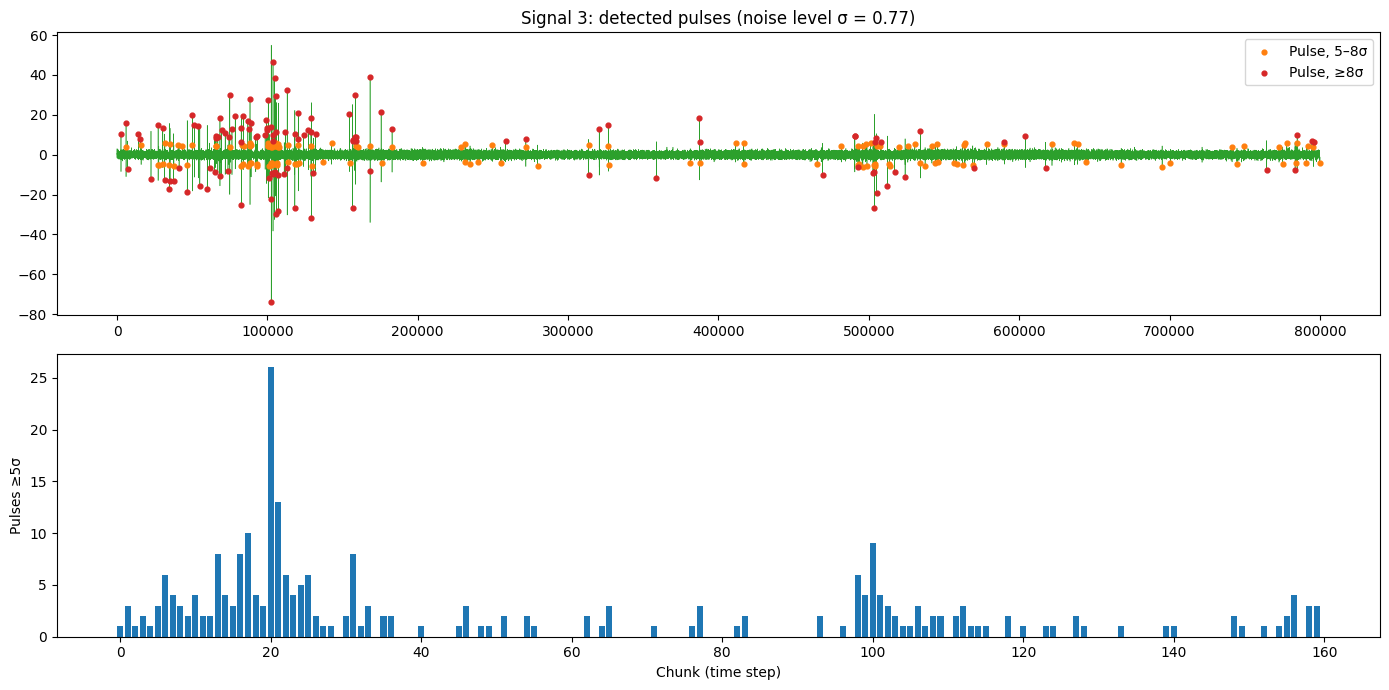

259 pulses detected (123 at least 8σ): 148 positive, 111 negative


In [4]:
sid = meta.loc[meta['target'] == 1, 'signal_id'].iloc[0]
raw = pq.read_table(f'{DATA_DIR}/train.parquet', columns=[str(sid)]).column(0).to_numpy()
x = wavelet_denoise(highpass(raw.astype(np.float32)))
peaks, heights, signs, sigma = find_pulses(x)
feats = pulse_features(x)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(x, linewidth=0.4, color='tab:green')
strong = heights >= PEAK_HIGH
axes[0].scatter(peaks[~strong], x[peaks[~strong]], s=12, color='tab:orange', label='Pulse, 5–8σ', zorder=3)
axes[0].scatter(peaks[strong], x[peaks[strong]], s=12, color='tab:red', label='Pulse, ≥8σ', zorder=3)
axes[0].set_title(f'Signal {sid}: detected pulses (noise level σ = {sigma:.2f})'); axes[0].legend()
axes[1].bar(np.arange(N_CHUNKS), feats[:, 0], color='tab:blue')
axes[1].set_xlabel('Chunk (time step)'); axes[1].set_ylabel('Pulses ≥5σ')
plt.tight_layout(); plt.show()
print(f'{len(peaks)} pulses detected ({strong.sum()} at least 8σ): {(signs > 0).sum()} positive, {(signs < 0).sum()} negative')

## 5. Process both datasets and save

The training data and the Kaggle test data are processed the same way, 300 signals at a time. Outputs:

| File | Contents |
|---|---|
| `X_train_v2.npy` | (8,712, 160, 12) features for the labelled signals |
| `meta_train_v2.csv` | Labelled-signal metadata with the v1 split |
| `X_kaggle_test_v2.npy` | (20,337, 160, 12) features for the Kaggle test signals |
| `meta_kaggle_test.csv` | Kaggle test metadata (no labels) |
| `feature_names.json` | The 12 feature names, in order |

In [5]:
def process(parquet_file, ids):
    X = np.zeros((len(ids), N_CHUNKS, N_FEATURES), dtype=np.float32)
    for start in tqdm(range(0, len(ids), 300), desc=parquet_file):
        batch = ids[start:start + 300]
        table = pq.read_table(f'{DATA_DIR}/{parquet_file}', columns=[str(s) for s in batch])
        for j, s in enumerate(batch):
            X[start + j] = preprocess(table.column(str(s)).to_numpy())
        del table
    return X

run_meta = meta.iloc[:LIMIT] if LIMIT else meta
run_kaggle = meta_kaggle.iloc[:LIMIT] if LIMIT else meta_kaggle

X_train = process('train.parquet', run_meta['signal_id'].values)
np.save(f'{OUT_DIR}/X_train_v2.npy', X_train)
run_meta.to_csv(f'{OUT_DIR}/meta_train_v2.csv', index=False)

X_kaggle = process('test.parquet', run_kaggle['signal_id'].values)
np.save(f'{OUT_DIR}/X_kaggle_test_v2.npy', X_kaggle)
run_kaggle.to_csv(f'{OUT_DIR}/meta_kaggle_test.csv', index=False)

with open(f'{OUT_DIR}/feature_names.json', 'w') as f:
    json.dump(FEATURE_NAMES, f)
print('Saved X_train_v2', X_train.shape, '| X_kaggle_test_v2', X_kaggle.shape)

train.parquet:   0%|          | 0/1 [00:00<?, ?it/s]

test.parquet:   0%|          | 0/1 [00:00<?, ?it/s]

Saved X_train_v2 (60, 160, 12) | X_kaggle_test_v2 (60, 160, 12)


## 6. Quick check: do the pulse features separate PD from normal signals?

For each signal, the total number of pulses (summed over all 160 chunks) is compared between PD and normal signals. If the PD average is clearly higher, the new features carry useful information.

In [6]:
total_pulses = X_train[:, :, FEATURE_NAMES.index('pulses_5sd')].sum(axis=1)
strong_pulses = X_train[:, :, FEATURE_NAMES.index('pulses_8sd')].sum(axis=1)
y_run = run_meta['target'].values
for label, name in [(1, 'PD'), (0, 'Normal')]:
    print(f'{name:6s} signals: average {total_pulses[y_run == label].mean():7.1f} pulses ≥5σ, '
          f'{strong_pulses[y_run == label].mean():6.1f} pulses ≥8σ')

PD     signals: average   216.3 pulses ≥5σ,  105.3 pulses ≥8σ
Normal signals: average   202.0 pulses ≥5σ,   71.1 pulses ≥8σ


## Next step

After the quick test works, set `LIMIT = None` in section 1 and commit with **Save & Run All**, naming the version something like `v2 - Pulse features + Kaggle test set`. When it finishes, the five files appear in the **Output** tab, ready for the Test 3 training notebook.